<a href="https://colab.research.google.com/github/RebeccaTsekanovskiy/CSCI_4170_Spring2026/blob/main/hw2_CSCI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 1 implement decision tree classifer

In [24]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayeshasiddiqa123/student-perfirmance")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-perfirmance' dataset.
Path to dataset files: /kaggle/input/student-perfirmance


In [25]:
import pandas as pd
import os

dataset_files = os.listdir(path)
print("Files in dataset path:", dataset_files)


csv_file_name = [f for f in dataset_files if f.endswith('.csv')][0]
csv_file_path = os.path.join(path, csv_file_name)

df = pd.read_csv(csv_file_path)

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Info:")
df.info()

Files in dataset path: ['StudentPerformanceFactors.csv']
First 5 rows of the DataFrame:
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

In [26]:
from sklearn.model_selection import train_test_split

print("\nMissing values before handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

for col in ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']:
    if col in df.columns and df[col].isnull().any():
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value) # Fix: Assign back directly instead of using inplace=True

print("\nMissing values after handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

categorical_cols = df.select_dtypes(include='object').columns
print(f"\nCategorical columns to encode: {list(categorical_cols)}")

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("\nDataFrame after one-hot encoding (first 5 rows):")
print(df_encoded.head())

df_encoded['is_high_score'] = (df_encoded['Exam_Score'] > 70).astype(int)
print("\nValue counts for 'is_high_score':")
print(df_encoded['is_high_score'].value_counts())

X = df_encoded.drop(columns=['Exam_Score', 'is_high_score'])
y = df_encoded['is_high_score']

print(f"\nShape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Missing values before handling:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Missing values after handling:
Series([], dtype: int64)

Categorical columns to encode: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

DataFrame after one-hot encoding (first 5 rows):
   Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  Tutoring_Sessions  \
0             23          84            7               73                  0   
1             19          64            8               59                  2   
2             24          98            7               91                  2   
3             29          89            8               98                  1   
4             19          92            6     

## Task1 - visualize decison tree for at least there different paramter settings.

In [27]:
from sklearn.tree import DecisionTreeClassifier

max_depth_values = [3, 5, 7]

dt_models = {}

print("Training Decision Tree models with different max_depth values...")
for depth in max_depth_values:
    print(f"  Training model with max_depth={depth}")
    dt_classifier = DecisionTreeClassifier(max_depth=depth, random_state=42)

    dt_classifier.fit(X_train, y_train)

    dt_models[depth] = dt_classifier

print("Training complete. Stored models for max_depth:", list(dt_models.keys()))

Training Decision Tree models with different max_depth values...
  Training model with max_depth=3
  Training model with max_depth=5
  Training model with max_depth=7
Training complete. Stored models for max_depth: [3, 5, 7]


Generating visualizations for Decision Trees...
  Visualizing tree with max_depth=3...


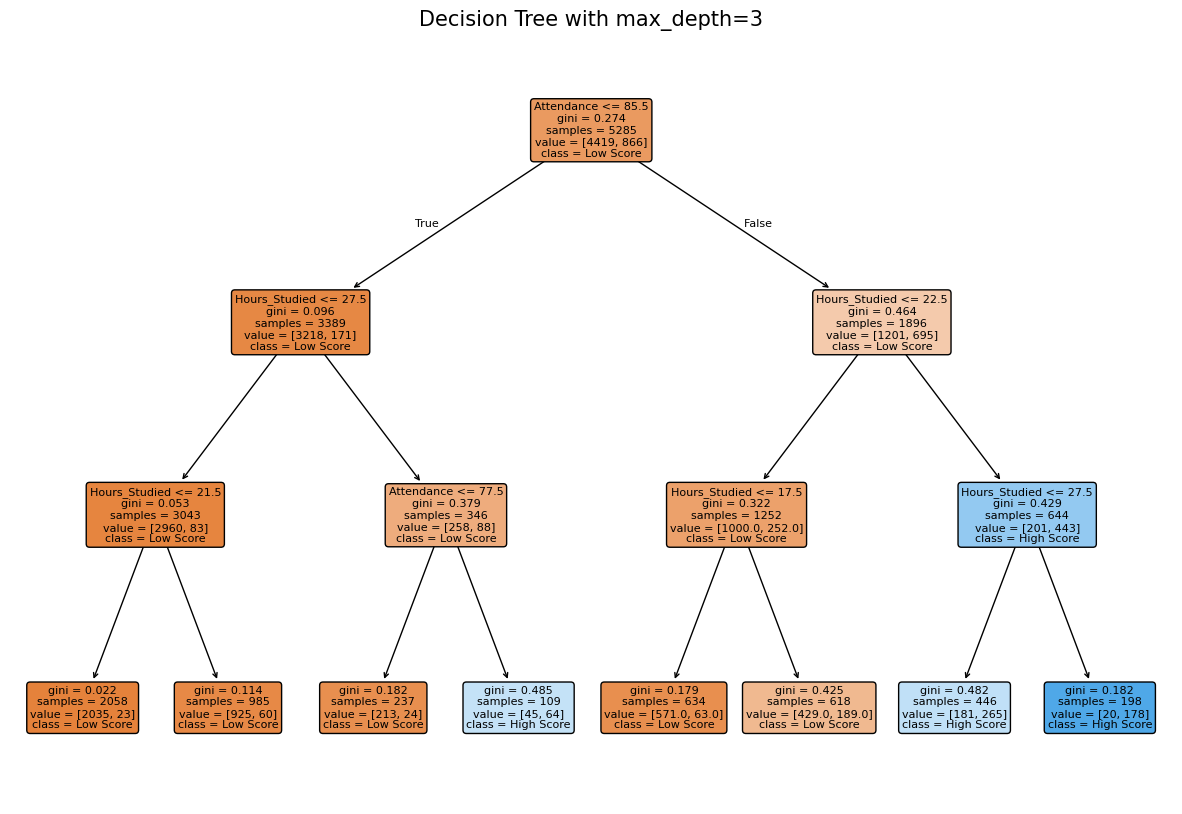

  Visualizing tree with max_depth=5...


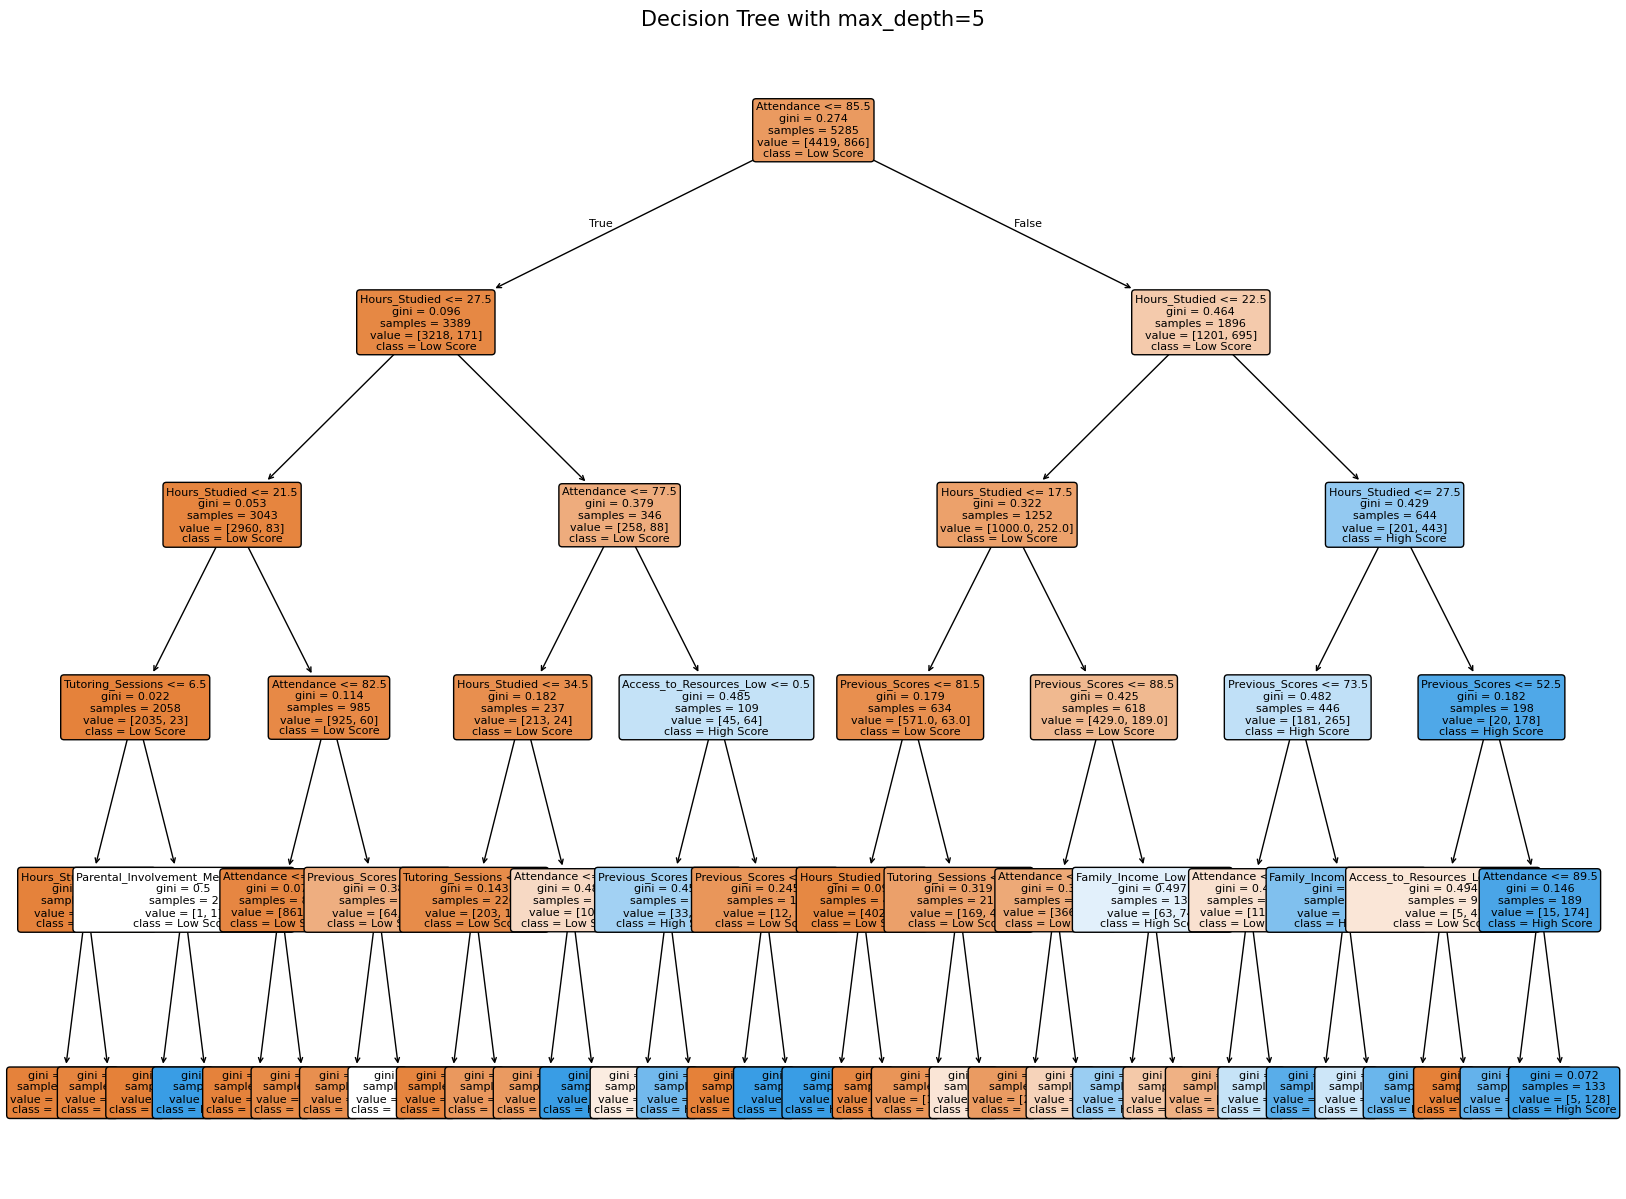

  Visualizing tree with max_depth=7...


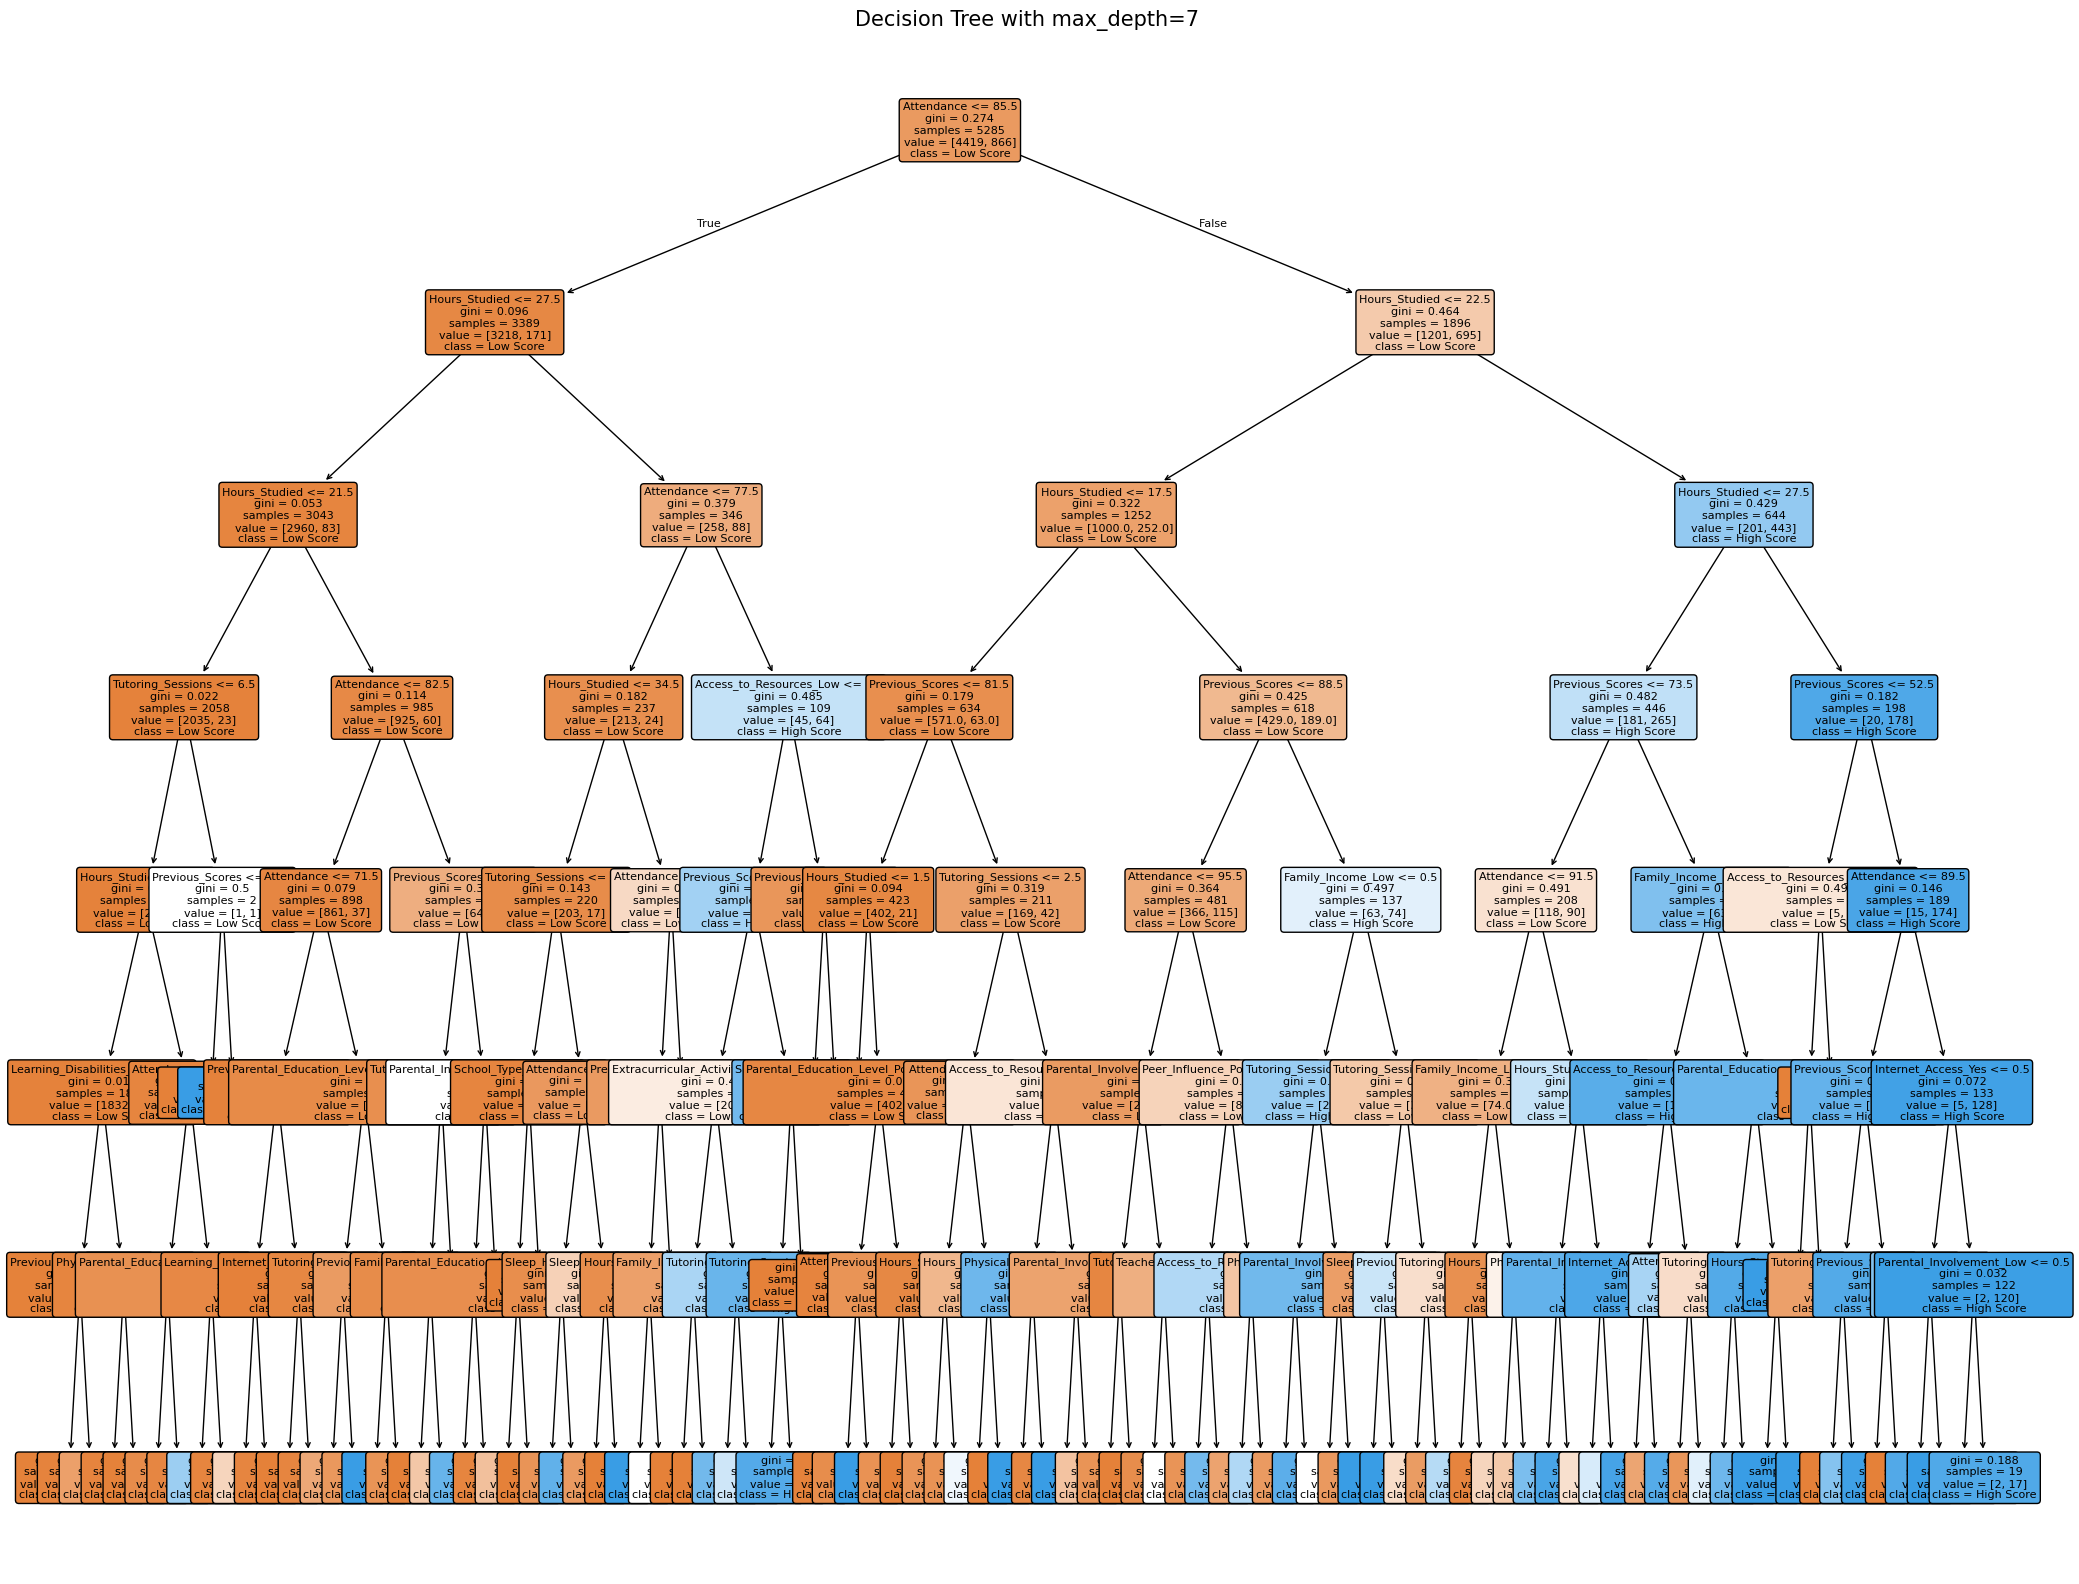

Visualizations complete.


In [28]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

class_names = ['Low Score', 'High Score']

print("Generating visualizations for Decision Trees...")
for depth, model in dt_models.items():
    print(f"  Visualizing tree with max_depth={depth}...")

    if depth == 3:
        fig_size = (15, 10)
    elif depth == 5:
        fig_size = (20, 15)
    else: # depth == 7 or higher
        fig_size = (25, 20)

    plt.figure(figsize=fig_size)
    plot_tree(
        model,
        feature_names=X.columns.tolist(), # Use feature names from the DataFrame
        class_names=class_names,
        filled=True,
        rounded=True,
        fontsize=8 # Adjust font size for better fit in larger trees
    )
    plt.title(f'Decision Tree with max_depth={depth}', fontsize=15)
    plt.show()
print("Visualizations complete.")

The depth in a decison tree directly impacts the complexity of the tree by causing there to be more decisions. As the max depth increases, there are also more nodes. By having a smaller max depth ( such as 3 ), the tree is easier to understand and explain because there is way less to take in and understand. Compared to a depth of 7, it is harder to interpret.

## Task 1 - sensitivty analysis

Sensitivty Analysis is how different variables will impact the result of a certain task. This is done by identifying variables that impact the outcomes and then understand the effects of those variables.

There are 5 types of sensitivty analyses. These include local, global, one way, two way, and probabilisitic sensitivty analysis.

https://www.quadratichq.com/blog/what-is-sensitivity-analysis-evaluating-risk-and-uncertainty


https://julius.ai/articles/sensitivity-analysis


To perform sensitivity analysis, I selected two input features and created a grid of possible values covering their observed ranges. For each point on the grid, I used the trained decision tree to predict the probability of the positive class, which allows me to visualize how the classification changes across the feature space

In [29]:
dt_model_5 = dt_models[5]
print(f"Selected Decision Tree model: {dt_model_5}")

features_to_vary = ['Hours_Studied', 'Previous_Scores']
print(f"Features selected for sensitivity analysis: {features_to_vary}")

Selected Decision Tree model: DecisionTreeClassifier(max_depth=5, random_state=42)
Features selected for sensitivity analysis: ['Hours_Studied', 'Previous_Scores']


In [30]:
import numpy as np

base_feature_vector = X_train.mean()
print("Base Feature Vector (mean of X_train features):\n", base_feature_vector.head())

hours_studied_range = np.linspace(X_train['Hours_Studied'].min(), X_train['Hours_Studied'].max(), 50)
previous_scores_range = np.linspace(X_train['Previous_Scores'].min(), X_train['Previous_Scores'].max(), 50)

hours_mesh, scores_mesh = np.meshgrid(hours_studied_range, previous_scores_range)

synthetic_data_points = []

for i in range(hours_mesh.shape[0]):
    for j in range(hours_mesh.shape[1]):
        current_hours = hours_mesh[i, j]
        current_scores = scores_mesh[i, j]

        synthetic_vector = base_feature_vector.copy()

        synthetic_vector['Hours_Studied'] = current_hours
        synthetic_vector['Previous_Scores'] = current_scores

        synthetic_data_points.append(synthetic_vector)

sensitivity_df = pd.DataFrame(synthetic_data_points, columns=X_train.columns)

print(f"\nShape of generated sensitivity DataFrame: {sensitivity_df.shape}")
print("First 5 rows of the sensitivity DataFrame:\n", sensitivity_df.head())

Base Feature Vector (mean of X_train features):
 Hours_Studied        19.933018
Attendance           79.939073
Sleep_Hours           7.043330
Previous_Scores      75.147398
Tutoring_Sessions     1.478146
dtype: float64

Shape of generated sensitivity DataFrame: (2500, 27)
First 5 rows of the sensitivity DataFrame:
    Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  Tutoring_Sessions  \
0       1.000000   79.939073      7.04333             50.0           1.478146   
1       1.857143   79.939073      7.04333             50.0           1.478146   
2       2.714286   79.939073      7.04333             50.0           1.478146   
3       3.571429   79.939073      7.04333             50.0           1.478146   
4       4.428571   79.939073      7.04333             50.0           1.478146   

   Physical_Activity  Parental_Involvement_Low  Parental_Involvement_Medium  \
0           2.978619                  0.200757                     0.512204   
1           2.978619                  

Shape of predicted probabilities: (2500,)
Shape of probability grid: (50, 50)
First few values of the probability grid:
 [[0.00865801 0.00865801 0.00865801 0.00865801 0.00865801]
 [0.00865801 0.00865801 0.00865801 0.00865801 0.00865801]
 [0.00865801 0.00865801 0.00865801 0.00865801 0.00865801]
 [0.00865801 0.00865801 0.00865801 0.00865801 0.00865801]
 [0.00865801 0.00865801 0.00865801 0.00865801 0.00865801]]


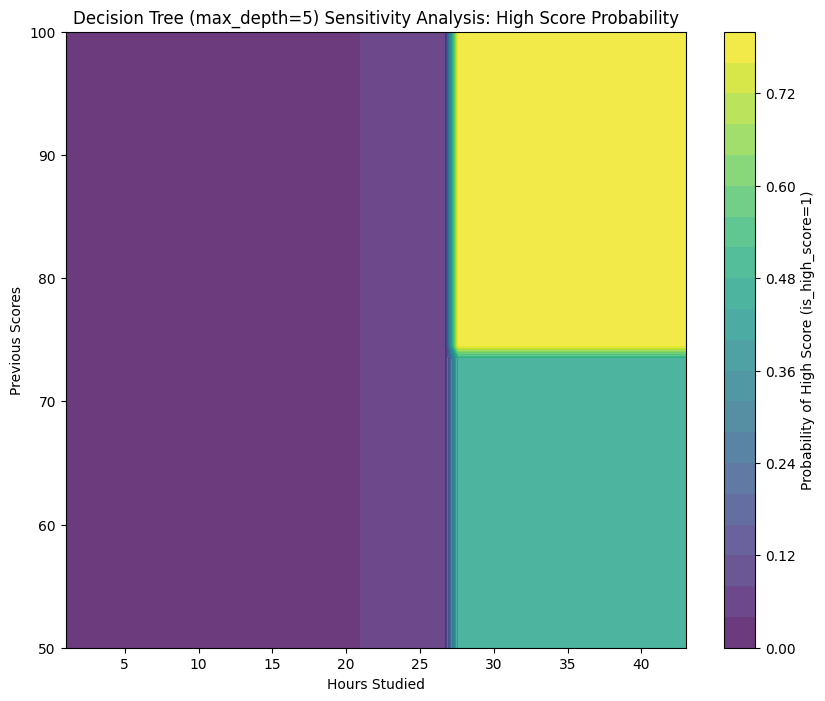

In [31]:
import matplotlib.pyplot as plt

predicted_probabilities = dt_model_5.predict_proba(sensitivity_df)[:, 1]

probability_grid = predicted_probabilities.reshape(hours_mesh.shape)

print(f"Shape of predicted probabilities: {predicted_probabilities.shape}")
print(f"Shape of probability grid: {probability_grid.shape}")
print("First few values of the probability grid:\n", probability_grid[:5, :5])

plt.figure(figsize=(10, 8))
contour = plt.contourf(hours_mesh, scores_mesh, probability_grid, levels=20, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Probability of High Score (is_high_score=1)')
plt.xlabel('Hours Studied')
plt.ylabel('Previous Scores')
plt.title('Decision Tree (max_depth=5) Sensitivity Analysis: High Score Probability')
plt.show()

Based off the sensitriivty analysis, with high interactions between hours studied and previous score.

# Task 2 Bagging and Boosting

K Fold Cross Validation:
It involves taking the dataset into equal k folders. The model is then trained k times, where one fold is used in the validation set.  

Stratified K Fold cross validation is a variation of K Fold cross validation that is useful when dealing with imbalanced datasets. The “stratification”  impacts this process by making sure each fold is about the same percentage of samples. This can be helpful when one class its rare.                                                                    The folds become more representative, making a more accurate model.


This is important for classification because it prevents one fold from accidentally having mostly one class, which would make evaluation unreliable. I tested multiple values of k (5, 10, and 15) to examine whether the model performance is stable across different validation granularities.


https://scikit-learn.org/stable/modules/cross_validation.html#stratified-k-fold


Bagging algorithm. This trains on different bootstrapped samples of the data and then averages their predictions.

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, f1_score
import numpy as np


n_splits_values = [5, 10, 15]

cv_results = {}

print("Starting Stratified K-Fold Cross-Validation for RandomForestClassifier...")

for n_splits in n_splits_values:
    print(f"\nPerforming cross-validation with n_splits={n_splits}")

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    fold_accuracies = []
    fold_precisions = []
    fold_f1_scores = []

    for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

        rf_classifier = RandomForestClassifier(random_state=42)

        rf_classifier.fit(X_train_fold, y_train_fold)

        y_pred_fold = rf_classifier.predict(X_test_fold)

        accuracy = accuracy_score(y_test_fold, y_pred_fold)
        precision = precision_score(y_test_fold, y_pred_fold, average='binary', zero_division=0)
        f1 = f1_score(y_test_fold, y_pred_fold, average='binary', zero_division=0)

        fold_accuracies.append(accuracy)
        fold_precisions.append(precision)
        fold_f1_scores.append(f1)

    avg_accuracy = np.mean(fold_accuracies)
    avg_precision = np.mean(fold_precisions)
    avg_f1_score = np.mean(fold_f1_scores)

    print(f"Average scores for n_splits={n_splits}: Accuracy={avg_accuracy:.4f}, Precision={avg_precision:.4f}, F1-Score={avg_f1_score:.4f}")

    cv_results[n_splits] = {
        'accuracy': avg_accuracy,
        'precision': avg_precision,
        'f1_score': avg_f1_score
    }

print("\nCross-validation complete. Results stored in 'cv_results'.")
print(cv_results)


Starting Stratified K-Fold Cross-Validation for RandomForestClassifier...

Performing cross-validation with n_splits=5
Average scores for n_splits=5: Accuracy=0.9196, Precision=0.9260, F1-Score=0.6918

Performing cross-validation with n_splits=10
Average scores for n_splits=10: Accuracy=0.9192, Precision=0.9287, F1-Score=0.6884

Performing cross-validation with n_splits=15
Average scores for n_splits=15: Accuracy=0.9216, Precision=0.9324, F1-Score=0.6998

Cross-validation complete. Results stored in 'cv_results'.
{5: {'accuracy': np.float64(0.9196318976248911), 'precision': np.float64(0.926005767403991), 'f1_score': np.float64(0.6917802826073473)}, 10: {'accuracy': np.float64(0.9191800761014075), 'precision': np.float64(0.9286849992570912), 'f1_score': np.float64(0.6884142903493411)}, 15: {'accuracy': np.float64(0.9216058544629974), 'precision': np.float64(0.9323556848715456), 'f1_score': np.float64(0.699799792920609)}}


Boosting trains the models in order, where each tree focuses on correcting the errors of the previous tree.

In [33]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, f1_score
import numpy as np

# n_splits_values = [5, 10, 15]

cv_results_gb = {}

print("Starting Stratified K-Fold Cross-Validation for GradientBoostingClassifier...")

for n_splits in n_splits_values:
    print(f"\nPerforming cross-validation with n_splits={n_splits}")

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    fold_accuracies_gb = []
    fold_precisions_gb = []
    fold_f1_scores_gb = []

    for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

        gb_classifier = GradientBoostingClassifier(random_state=42)

        gb_classifier.fit(X_train_fold, y_train_fold)

        y_pred_fold = gb_classifier.predict(X_test_fold)

        accuracy = accuracy_score(y_test_fold, y_pred_fold)
        precision = precision_score(y_test_fold, y_pred_fold, average='binary', zero_division=0)
        f1 = f1_score(y_test_fold, y_pred_fold, average='binary', zero_division=0)

        fold_accuracies_gb.append(accuracy)
        fold_precisions_gb.append(precision)
        fold_f1_scores_gb.append(f1)

    avg_accuracy_gb = np.mean(fold_accuracies_gb)
    avg_precision_gb = np.mean(fold_precisions_gb)
    avg_f1_score_gb = np.mean(fold_f1_scores_gb)

    print(f"Average scores for n_splits={n_splits}: Accuracy={avg_accuracy_gb:.4f}, Precision={avg_precision_gb:.4f}, F1-Score={avg_f1_score_gb:.4f}")

    cv_results_gb[n_splits] = {
        'accuracy': avg_accuracy_gb,
        'precision': avg_precision_gb,
        'f1_score': avg_f1_score_gb
    }

print("\nCross-validation complete for GradientBoostingClassifier. Results stored in 'cv_results_gb'.")
print(cv_results_gb)

Starting Stratified K-Fold Cross-Validation for GradientBoostingClassifier...

Performing cross-validation with n_splits=5
Average scores for n_splits=5: Accuracy=0.9389, Precision=0.8918, F1-Score=0.7927

Performing cross-validation with n_splits=10
Average scores for n_splits=10: Accuracy=0.9382, Precision=0.8960, F1-Score=0.7887

Performing cross-validation with n_splits=15
Average scores for n_splits=15: Accuracy=0.9386, Precision=0.8932, F1-Score=0.7905

Cross-validation complete for GradientBoostingClassifier. Results stored in 'cv_results_gb'.
{5: {'accuracy': np.float64(0.9388531129284765), 'precision': np.float64(0.8917786514135777), 'f1_score': np.float64(0.7927468357805016)}, 10: {'accuracy': np.float64(0.9382489799660754), 'precision': np.float64(0.8960470126148165), 'f1_score': np.float64(0.7886592842357707)}, 15: {'accuracy': np.float64(0.9385518449804164), 'precision': np.float64(0.8932349454406079), 'f1_score': np.float64(0.790473296376758)}}


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_for_df = []

for n_splits, metrics in cv_results.items():
    for metric_name, score in metrics.items():
        data_for_df.append({
            'n_splits': n_splits,
            'Model': 'RandomForestClassifier',
            'Metric': metric_name,
            'Score': score
        })

for n_splits, metrics in cv_results_gb.items():
    for metric_name, score in metrics.items():
        data_for_df.append({
            'n_splits': n_splits,
            'Model': 'GradientBoostingClassifier',
            'Metric': metric_name,
            'Score': score
        })

comparison_df = pd.DataFrame(data_for_df)

print("Comparison DataFrame (first 5 rows):")
print(comparison_df.head())
print("\nComparison DataFrame info:")
comparison_df.info()

Comparison DataFrame (first 5 rows):
   n_splits                   Model     Metric     Score
0         5  RandomForestClassifier   accuracy  0.919632
1         5  RandomForestClassifier  precision  0.926006
2         5  RandomForestClassifier   f1_score  0.691780
3        10  RandomForestClassifier   accuracy  0.919180
4        10  RandomForestClassifier  precision  0.928685

Comparison DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   n_splits  18 non-null     int64  
 1   Model     18 non-null     object 
 2   Metric    18 non-null     object 
 3   Score     18 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 708.0+ bytes


The boosting algorithm shows a higher average across all the splits, compared to RandomForestClassifier.
The gradient boosting algorithm makes more correct predictions than the random forest algorithms. I do not see any signifcant variation in accuracy for either model. This means there is not a chosen number of folds that impact the overall accuracy of these models.


For precision, Random forest has a higher precision compared to Gradient Boosting. This means, everytime it predicts the score, it is more likely to be correct.

For the f1 score,  the gradient boosting outperforms RandomForest. This higher f1 score implies a better balance between identifying the good scoring students and ensuring identifications are correct.

Based off these results, if the accuracy score is the main concern, GradientBoosting is the best choice. If precision is most important, then Random Forest is best choice.


Because each metric emphasizes different kinds of errors, the ranking between bagging and boosting can change depending on whether the metric rewards conservative predictions (precision) or balanced performance (F1).

## Task 3 Compare the effectiveness of the three models implemented above

Shape of X_train_fold: (5285, 27)
Shape of X_test_fold: (1322, 27)
Shape of y_train_fold: (5285,)
Shape of y_test_fold: (1322,)


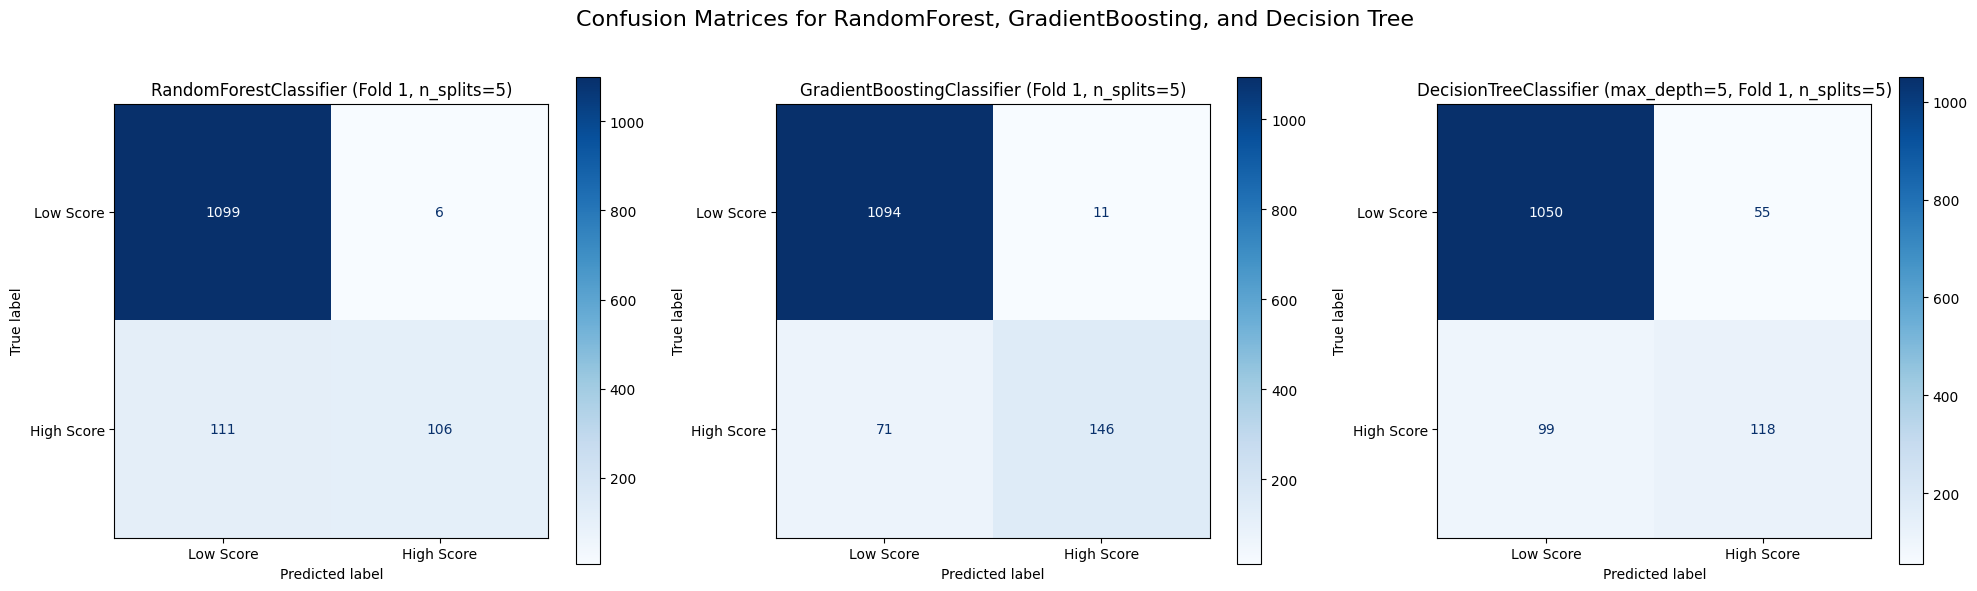

Confusion matrices generated and displayed successfully for all three models.


In [35]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier # Import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

first_fold_train_index, first_fold_test_index = list(skf.split(X, y))[0]

X_train_fold = X.iloc[first_fold_train_index]
X_test_fold = X.iloc[first_fold_test_index]
y_train_fold = y.iloc[first_fold_train_index]
y_test_fold = y.iloc[first_fold_test_index]

print(f"Shape of X_train_fold: {X_train_fold.shape}")
print(f"Shape of X_test_fold: {X_test_fold.shape}")
print(f"Shape of y_train_fold: {y_train_fold.shape}")
print(f"Shape of y_test_fold: {y_test_fold.shape}")

rf_classifier_fold = RandomForestClassifier(random_state=42)
rf_classifier_fold.fit(X_train_fold, y_train_fold)

y_pred_rf = rf_classifier_fold.predict(X_test_fold)

gb_classifier_fold = GradientBoostingClassifier(random_state=42)
gb_classifier_fold.fit(X_train_fold, y_train_fold)

y_pred_gb = gb_classifier_fold.predict(X_test_fold)
dt_classifier_fold = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_classifier_fold.fit(X_train_fold, y_train_fold)

y_pred_dt = dt_classifier_fold.predict(X_test_fold)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices for RandomForest, GradientBoosting, and Decision Tree', fontsize=16)

cmd_rf = ConfusionMatrixDisplay.from_predictions(
    y_true=y_test_fold,
    y_pred=y_pred_rf,
    cmap='Blues',
    display_labels=['Low Score', 'High Score'],
    ax=axes[0]
)
axes[0].set_title('RandomForestClassifier (Fold 1, n_splits=5)', fontsize=12)

cmd_gb = ConfusionMatrixDisplay.from_predictions(
    y_true=y_test_fold,
    y_pred=y_pred_gb,
    cmap='Blues',
    display_labels=['Low Score', 'High Score'],
    ax=axes[1]
)
axes[1].set_title('GradientBoostingClassifier (Fold 1, n_splits=5)', fontsize=12)

cmd_dt = ConfusionMatrixDisplay.from_predictions(
    y_true=y_test_fold,
    y_pred=y_pred_dt,
    cmap='Blues',
    display_labels=['Low Score', 'High Score'],
    ax=axes[2]
)
axes[2].set_title('DecisionTreeClassifier (max_depth=5, Fold 1, n_splits=5)', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("Confusion matrices generated and displayed successfully for all three models.")

In [36]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score
import numpy as np

print("Collecting individual F1-scores for RandomForestClassifier (n_splits=15)...")
skf_rf_15 = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)
rf_f1_scores_per_fold = []

for fold, (train_index, test_index) in enumerate(skf_rf_15.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    rf_classifier = RandomForestClassifier(random_state=42)
    rf_classifier.fit(X_train_fold, y_train_fold)
    y_pred_rf = rf_classifier.predict(X_test_fold)

    f1 = f1_score(y_test_fold, y_pred_rf, average='binary', zero_division=0)
    rf_f1_scores_per_fold.append(f1)

print(f"RandomForestClassifier F1-scores per fold (n_splits=15): {rf_f1_scores_per_fold}")
print(f"Average F1-score for RandomForestClassifier (n_splits=15): {np.mean(rf_f1_scores_per_fold):.4f}\n")

print("Collecting individual F1-scores for GradientBoostingClassifier (n_splits=15)...")
skf_gb_15 = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)
gb_f1_scores_per_fold = []

for fold, (train_index, test_index) in enumerate(skf_gb_15.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    gb_classifier = GradientBoostingClassifier(random_state=42)
    gb_classifier.fit(X_train_fold, y_train_fold)
    y_pred_gb = gb_classifier.predict(X_test_fold)

    f1 = f1_score(y_test_fold, y_pred_gb, average='binary', zero_division=0)
    gb_f1_scores_per_fold.append(f1)

print(f"GradientBoostingClassifier F1-scores per fold (n_splits=15): {gb_f1_scores_per_fold}")
print(f"Average F1-score for GradientBoostingClassifier (n_splits=15): {np.mean(gb_f1_scores_per_fold):.4f}")

print("Individual F1-scores for n_splits=15 collected successfully for both models.")

RandomForestClassifier F1-scores per fold (n_splits=15): [0.6666666666666666, 0.7008547008547008, 0.6095238095238096, 0.6782608695652174, 0.6833333333333333, 0.7058823529411765, 0.6363636363636364, 0.6666666666666666, 0.7933884297520661, 0.7017543859649122, 0.7563025210084033, 0.6422018348623854, 0.7936507936507936, 0.7288135593220338, 0.7333333333333333]
Average F1-score for RandomForestClassifier (n_splits=15): 0.6998

GradientBoostingClassifier F1-scores per fold (n_splits=15): [0.7936507936507936, 0.7727272727272727, 0.7868852459016393, 0.8062015503875969, 0.7910447761194029, 0.7751937984496124, 0.7596899224806202, 0.7559055118110236, 0.7910447761194029, 0.768, 0.8153846153846154, 0.7317073170731707, 0.8714285714285714, 0.8, 0.8382352941176471]
Average F1-score for GradientBoostingClassifier (n_splits=15): 0.7905
Individual F1-scores for n_splits=15 collected successfully for both models.


In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

skf_dt_15 = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)
dt_f1_scores_per_fold = []

for train_index, test_index in skf_dt_15.split(X, y):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    dt = DecisionTreeClassifier(max_depth=5, random_state=42)
    dt.fit(X_train_fold, y_train_fold)
    y_pred_dt = dt.predict(X_test_fold)

    dt_f1_scores_per_fold.append(f1_score(y_test_fold, y_pred_dt, zero_division=0))

print("DecisionTree F1 per fold:", dt_f1_scores_per_fold)
print("DecisionTree mean F1:", np.mean(dt_f1_scores_per_fold))


DecisionTree F1 per fold: [0.6771653543307087, 0.6363636363636364, 0.6153846153846154, 0.5846153846153846, 0.60431654676259, 0.6268656716417911, 0.512396694214876, 0.5882352941176471, 0.6290322580645161, 0.6870229007633588, 0.6618705035971223, 0.5984251968503937, 0.7464788732394366, 0.6456692913385826, 0.6766917293233082]
DecisionTree mean F1: 0.6327022633738646


To test whether the models differ significantly, I used a paired t-test on the fold-by-fold evaluation scores. The paired t-test is appropriate here because each model is evaluated on the same folds, so the scores are paired observations.

In [37]:
from scipy import stats

alpha = 0.05

print("\n--- Paired t-test: RandomForestClassifier vs. GradientBoostingClassifier ---")
t_statistic_rf_gb, p_value_rf_gb = stats.ttest_rel(rf_f1_scores_per_fold, gb_f1_scores_per_fold)
print(f"  T-statistic: {t_statistic_rf_gb:.4f}")
if p_value_rf_gb < alpha:
    print("  Conclusion: Statistically significant difference (reject H0).")
else:
    print("  Conclusion: No statistically significant difference (fail to reject H0).")

print("\n--- Paired t-test: RandomForestClassifier vs. DecisionTreeClassifier ---")
t_statistic_rf_dt, p_value_rf_dt = stats.ttest_rel(rf_f1_scores_per_fold, dt_f1_scores_per_fold)
print(f"  T-statistic: {t_statistic_rf_dt:.4f}")
if p_value_rf_dt < alpha:
    print("  Conclusion: Statistically significant difference (reject H0).")
else:
    print("  Conclusion: No statistically significant difference (fail to reject H0).")

print("\n--- Paired t-test: GradientBoostingClassifier vs. DecisionTreeClassifier ---")
t_statistic_gb_dt, p_value_gb_dt = stats.ttest_rel(gb_f1_scores_per_fold, dt_f1_scores_per_fold)
print(f"  T-statistic: {t_statistic_gb_dt:.4f}")
if p_value_gb_dt < alpha:
    print("  Conclusion: Statistically significant difference (reject H0).")
else:
    print("  Conclusion: No statistically significant difference (fail to reject H0).")

print("\nAll pairwise paired t-tests completed and interpreted.")


--- Paired t-test: RandomForestClassifier vs. GradientBoostingClassifier ---
  T-statistic: -8.5921
  Conclusion: Statistically significant difference (reject H0).

--- Paired t-test: RandomForestClassifier vs. DecisionTreeClassifier ---
  T-statistic: 5.6176
  Conclusion: Statistically significant difference (reject H0).

--- Paired t-test: GradientBoostingClassifier vs. DecisionTreeClassifier ---
  T-statistic: 15.0429
  Conclusion: Statistically significant difference (reject H0).

All pairwise paired t-tests completed and interpreted.


### Discussion on the trade off between bias and variance for each model

====
Decision Tree:
- Bias: there is moderate to high bias. This is because it can be oversimplifying the data and have underfitting
- Variance: There is moderate variance for max depth of 5 because
----
Random Forest
- Bias: the overall bias of the Random Forest tends to capture more patterns by combining many different trees.
- Variance:This is a low variance model. This is because RandomForest averages across bootstrapped samples.
------
Gradient Boosting
- Bias: There is usually low to moderate bias. This is because Gradient Boosting builds trees in a sequential order, where each new tree corrects the mistakes of the previous ones, so it can fit complex patterns better than a single shallow tree.
- Variance: Moderate to high variance. This can be from if you use to many trees.

---

overall summary:

Looking at the average F1-scores for 15-fold cross-validation, GradientBoostingClassifier has the highest mean F1 (0.7905), followed by RandomForestClassifier (0.6998), and then the DecisionTreeClassifier (0.6327). Since the paired t-tests reject H₀ for every pairwise comparison, the ordering seen in the mean F1 results reflects a real a perfomrnace difference. One likely reason the F1 score is lower is that the dataset may have an uneven number of samples per class, which can cause the model to miss minority class casess more often.